<center>
### Prédiction météo à l'aide de RNN (LSTM) dans PyTorch ###
</center>

#### Install and import libraries ####

In [125]:
import numpy as np                  # Nopérations numériques
import pandas as pd                 # Data manipulation
import matplotlib.pyplot as plt     # Plotting

import torch                        # Core PyTorch library
import torch.nn as nn               # Neural network modules
from torch.utils.data import Dataset, DataLoader  # Dataset & batching

from sklearn.preprocessing import MinMaxScaler    # For normalization

#### Load and preprocess the dataset ####

In [126]:
# Load the CSV file (change path if needed)
df = pd.read_csv("seattle-weather.csv")

# Remove rows where temperature is missing
df = df.dropna(subset=["temp_max"])

# Extract temperature column and reshape to (N,1)
temps = df["temp_max"].values.reshape(-1, 1)
    #.reshape(-1, 1)
    #signifie :
        # -1 : NumPy calcule automatiquement le nombre de lignes 𝑁
        # 1 : on veut une seule colonne.  
        # Donc la forme devient : (𝑁,1), c’est-à-dire une matrice colonne

# Normalize data into [0,1] range for stable training
scaler = MinMaxScaler()
scaled = scaler.fit_transform(temps)
print(df.head(10))

         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain
5  2012-01-06            2.5       4.4       2.2   2.2     rain
6  2012-01-07            0.0       7.2       2.8   2.3     rain
7  2012-01-08            0.0      10.0       2.8   2.0      sun
8  2012-01-09            4.3       9.4       5.0   3.4     rain
9  2012-01-10            1.0       6.1       0.6   3.4     rain


#### Create sequences for time serie ####

In [127]:
# RNNs need sequences: past values → predict next value
def make_sequences(data, window_size=10):
    """
    data: normalized temperature values
    window_size: number of past time steps used as input
    """
    X, y = [], []
    for i in range(window_size, len(data)):
        # Input: previous window_size values
        X.append(data[i-window_size:i])
        # Output: the next value
        y.append(data[i])
    return np.array(X), np.array(y)

WINDOW = 10
X, y = make_sequences(scaled, WINDOW)

# Convert numpy arrays to PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)  # (samples, timesteps, features)
y = torch.tensor(y, dtype=torch.float32)  # (samples, 1)

#### Split data into Train / Validation / Test ####

In [128]:
# Important: NO shuffle because time order must be preserved

train_size = int(0.7 * len(X))
val_size   = int(0.15 * len(X))

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]


#### Dataset class ####

In [129]:
# Allows PyTorch DataLoader to fetch batches

class WeatherDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        # Total number of samples
        return len(self.X)
    
    def __getitem__(self, idx):
        # Returns one sample (X, y)
        return self.X[idx], self.y[idx]

#### Create dataset objects ####

In [130]:
train_dataset = WeatherDataset(X_train, y_train)
val_dataset   = WeatherDataset(X_val, y_val)
test_dataset  = WeatherDataset(X_test, y_test)

# DataLoaders handle batching
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

#### Define the LSTM model ####

In [131]:
class WeatherRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=3, dropout=0.2):
        """
        input_size  : number of input features (1 = temperature)
        hidden_size : number of neurons in each LSTM layer
        num_layers  : number of stacked LSTM layers
        dropout     : regularization to reduce overfitting
        """
        super(WeatherRNN, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layer(s)
        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,  # (batch, seq, feature)
            dropout=dropout
        )
        
        # Fully connected layer for final prediction
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        """
        x shape: (batch_size, sequence_length, input_size)
        """
        # Initialize hidden state (h0) and cell state (c0) with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        # Pass through LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # Take output from the last time step
        out = out[:, -1, :]
        
        # Pass through fully connected layer
        out = self.fc(out)
        return out

####

#### Initialize model, loss function, and optimizer ####

In [132]:
model = WeatherRNN(input_size=1, hidden_size=50, num_layers=3, dropout=0.2)

# Mean Squared Error for regression
criterion = nn.MSELoss()

# Adam optimizer for faster convergence
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

#### Training function ####

In [133]:
def train_model(model, train_loader, val_loader, epochs=50):
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()          # Reset gradients
            outputs = model(X_batch)       # Forward pass
            loss = criterion(outputs, y_batch)  # Compute loss
            loss.backward()                # Backpropagation
            optimizer.step()               # Update weights
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0
        with torch.no_grad():              # No gradient tracking
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.6f} "
              f"Val Loss: {val_loss:.6f}")
    
    return train_losses, val_losses

#### Train the model ####

In [134]:
train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=100)

Epoch [1/100] Train Loss: 0.090623 Val Loss: 0.013463
Epoch [2/100] Train Loss: 0.040263 Val Loss: 0.023326
Epoch [3/100] Train Loss: 0.038434 Val Loss: 0.021699
Epoch [4/100] Train Loss: 0.027530 Val Loss: 0.016991
Epoch [5/100] Train Loss: 0.014094 Val Loss: 0.009118
Epoch [6/100] Train Loss: 0.013076 Val Loss: 0.009016
Epoch [7/100] Train Loss: 0.012482 Val Loss: 0.009440
Epoch [8/100] Train Loss: 0.012234 Val Loss: 0.009454
Epoch [9/100] Train Loss: 0.012272 Val Loss: 0.009272
Epoch [10/100] Train Loss: 0.012117 Val Loss: 0.009552
Epoch [11/100] Train Loss: 0.011905 Val Loss: 0.009473
Epoch [12/100] Train Loss: 0.012178 Val Loss: 0.009624
Epoch [13/100] Train Loss: 0.012687 Val Loss: 0.009183
Epoch [14/100] Train Loss: 0.012055 Val Loss: 0.009182
Epoch [15/100] Train Loss: 0.011937 Val Loss: 0.009161
Epoch [16/100] Train Loss: 0.011855 Val Loss: 0.009065
Epoch [17/100] Train Loss: 0.011285 Val Loss: 0.009301
Epoch [18/100] Train Loss: 0.011411 Val Loss: 0.009160
Epoch [19/100] Trai

#### Plot training and validation loss ####

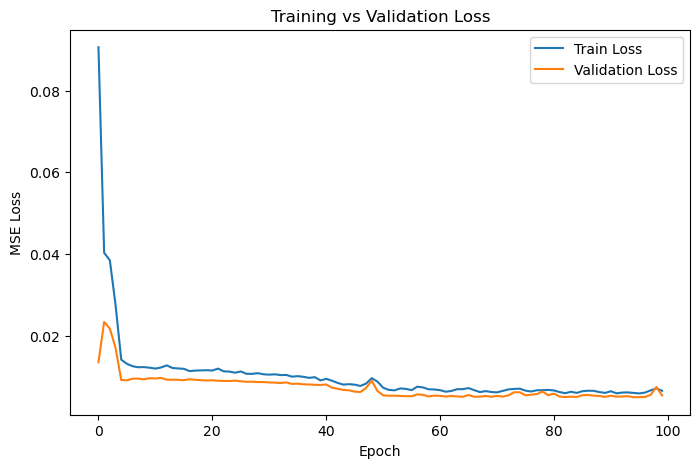

In [135]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

#### Test and make predictions ####

In [136]:
model.eval()
preds = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds.append(outputs.numpy())
        actuals.append(y_batch.numpy())

# Combine all batches
preds = np.vstack(preds)
actuals = np.vstack(actuals)

# Convert back to real temperature scale
preds = scaler.inverse_transform(preds)
actuals = scaler.inverse_transform(actuals)

#### Plot Actual vs Predicted values  ####

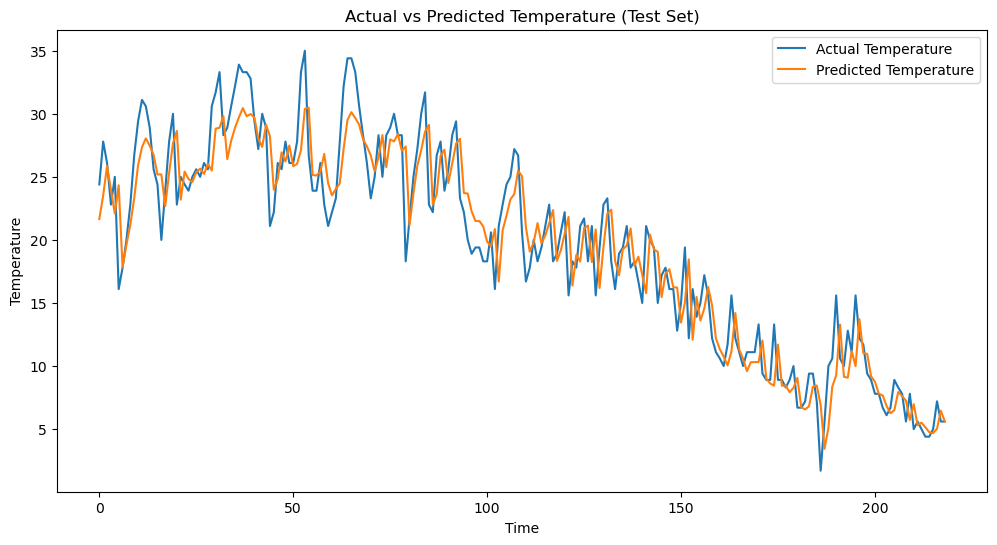

In [137]:
plt.figure(figsize=(12,6))
plt.plot(actuals, label="Actual Temperature")
plt.plot(preds, label="Predicted Temperature")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.title("Actual vs Predicted Temperature (Test Set)")
plt.legend()
plt.show()